In [119]:
import pandas as pd

In [120]:
df = pd.read_csv('/content/drive/MyDrive/llm_price_performance_tracker_2026-03-31.csv')
df['blended_cost_usd_per_1m'] = df['blended_cost_usd_per_1m'].fillna(0)
print(len(df))

453


In [121]:
top3 = (df.dropna(subset=["chatbot_arena_elo"]).sort_values("chatbot_arena_elo", ascending=False).head(3)["model_name"].tolist())
print(f"\nTop 3 by ELO: {top3}")


Top 3 by ELO: ['Claude Opus 4.6 (Non-reasoning, High Effort)', 'Gemini 3.1 Pro Preview', 'Gemini 3 Pro Preview (high)']


In [122]:
FEATURES = ["aa_intelligence_index", "composite_benchmark", "output_tokens_per_second", "time_to_first_token_s"]
TARGET = "blended_cost_usd_per_1m"
numeric_df = df[FEATURES + [TARGET]].dropna()
X = numeric_df[FEATURES]
y = numeric_df[TARGET]
print(len(numeric_df))

276


In [123]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [125]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [126]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print(f"\nMSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (in $/1M tokens)")
print(f"R²   : {r2:.4f}")


MSE  : 36.4254
RMSE : 6.0353  (in $/1M tokens)
R²   : 0.0701


In [127]:
coef_df = pd.DataFrame({"feature":FEATURES, "coefficient": model.coef_}).sort_values("coefficient", key=abs, ascending=False)

print("\nFeature coefficients (scaled):")
print(coef_df.to_string(index=False))


Feature coefficients (scaled):
                 feature  coefficient
   time_to_first_token_s     0.799680
output_tokens_per_second    -0.516186
     composite_benchmark     0.487876
   aa_intelligence_index     0.415439


In [128]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)
top3_df = df[df["model_name"].isin(top3)][FEATURES + ["model_name", TARGET]]
top3_imputed = imputer.transform(top3_df[FEATURES])
top3_scaled  = scaler.transform(top3_imputed)
top3_df = top3_df.copy()
top3_df["predicted_cost"] = model.predict(top3_scaled)
print("\nTop 3 — Actual vs Predicted blended cost ($/1M tokens):")
print(top3_df[["model_name", TARGET, "predicted_cost"]].to_string(index=False))


Top 3 — Actual vs Predicted blended cost ($/1M tokens):
                                  model_name  blended_cost_usd_per_1m  predicted_cost
                      Gemini 3.1 Pro Preview                      4.5        4.628374
                 Gemini 3 Pro Preview (high)                      4.5        4.594146
Claude Opus 4.6 (Non-reasoning, High Effort)                     10.0        2.668106


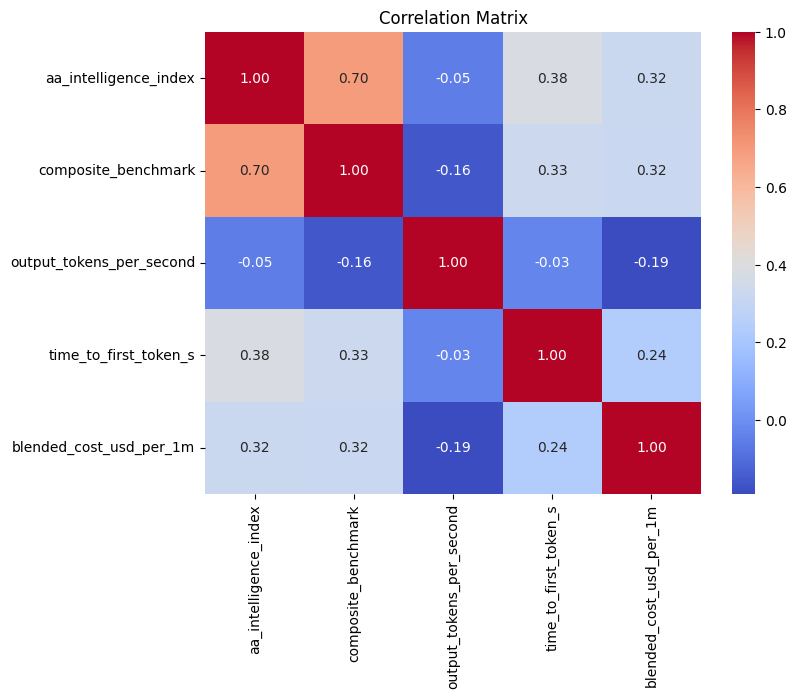

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

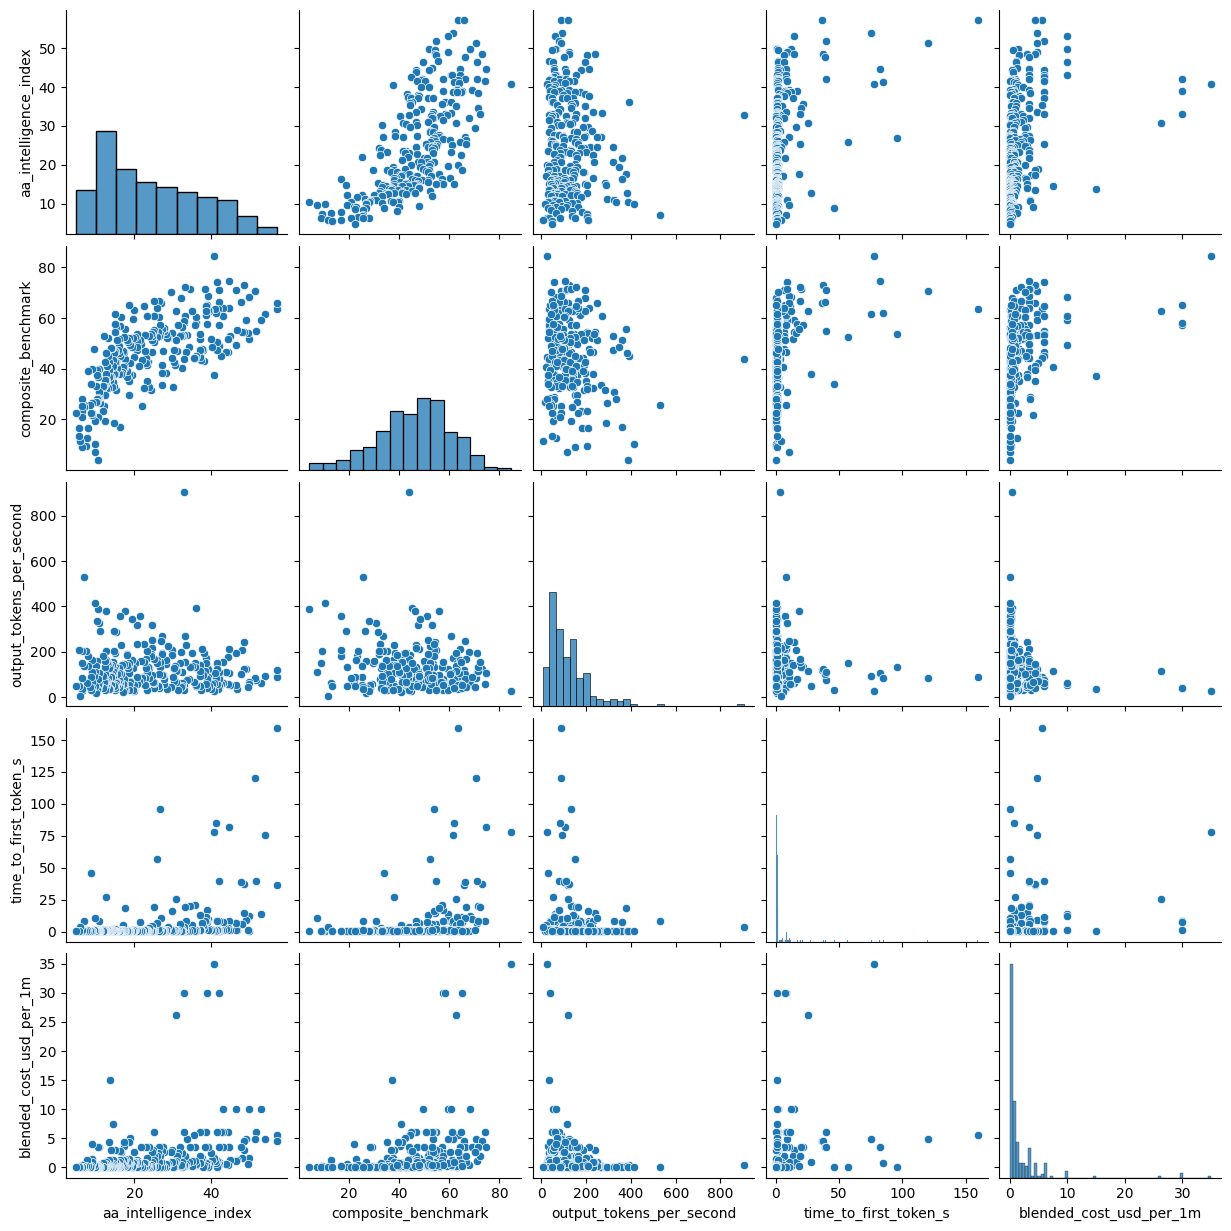

In [130]:
sns.pairplot(numeric_df)
plt.show()

In [132]:
from sklearn.linear_model import Ridge

df_model = df[FEATURES + ["pricing_tier", "provider", TARGET]].dropna(subset=FEATURES + [TARGET])

df_model = pd.get_dummies(df_model, columns=["pricing_tier", "provider"], drop_first=True)
tier_cols  = [c for c in df_model.columns if "pricing_tier" in c]
prov_cols  = [c for c in df_model.columns if "provider" in c]

FEATURES = [
    "aa_intelligence_index",
    "composite_benchmark",
    "output_tokens_per_second",
    "time_to_first_token_s",
] + tier_cols + prov_cols

X = df_model[FEATURES]
y = df_model[TARGET]
y_log = np.log1p(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)
y_pred_log = model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mse  = mean_squared_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {mse**0.5:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 5.7942
RMSE : 2.4071
R²   : 0.8521
